# 53.1 · Versioned inference and operational metrics

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain versioned inference and operational metrics using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[41 · Multimodal Computer Vision](../../41-multimodal-computer-vision/README.md), [50 · Computer Vision Deployment](../../50-computer-vision-deployment/README.md), [51 · Edge AI](../../51-edge-ai/README.md), [52 · Real-Time Computer Vision](../../52-real-time-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Production computer vision combines data, models, software and operations. A trained checkpoint is one component of a system that must remain observable and maintainable. Monitoring detects changes, while labeled evaluation determines whether those changes hurt the task.

## 2. Intuition

Record model version, preprocessing version, label map and configuration with every deployment. Log bounded metadata and avoid unnecessary image retention. Track errors, request counts and latency distributions. A reproducible artifact allows a previous model to be restored when a release causes a regression.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 53
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
PSI=\sum_b(p_b-q_b)\log(p_b/q_b)
$$

pb and qb are current and reference proportions in fixed bins. Small smoothing avoids division by zero. PSI is zero for identical distributions; its thresholds are context-dependent and do not measure model accuracy.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
reference = np.array([0.5, 0.5])
current = np.array([0.5, 0.5])
psi = np.sum((current - reference) * np.log(current / reference))
assert np.isclose(psi, 0)
print(psi)

0.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab processes a generated video through the engine, persists real numeric events and measures an injected intensity distribution shift. The capstone links these stages to API and dashboard behavior.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def production(lesson=0, seed=42, amount=1.0):
    from cvzero.platform.engine import Engine
    from cvzero.platform.store import EventStore

    rng = np.random.default_rng(seed)
    reference = rng.normal(120, 20, 500)
    current = rng.normal(120 + 20 * amount, 25, 500)
    counts = []
    times = []
    engine = Engine()
    with tempfile.TemporaryDirectory() as folder:
        store = EventStore(Path(folder) / "events.sqlite")
        for i, frame in enumerate(video_frames(12)):
            rgb = frame.copy() if frame.ndim == 3 else cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
            rgb[..., 1] = 0
            report, _ = engine.analyze(rgb)
            store.append("smoke", i, float(i) / 30, report)
            counts.append(report["count"])
            times.append(report["latency_ms"])
        events = store.history("smoke")
    return Result(
        "53 · Monitoring and reproducible event logs",
        curves={"Frame→engine milliseconds": times, "Frame→detections": counts},
        panels={
            "Reference intensity histogram": np.histogram(reference, bins=20, range=(0, 255))[0],
            "Shifted intensity histogram": np.histogram(current, bins=20, range=(0, 255))[0],
        },
        metrics={
            "stored_events": len(events),
            "intensity_psi": population_stability(reference, current),
            "engine_p95_ms": float(np.percentile(times, 95)),
        },
        notes="PSI detects a distribution change in a synthetic scalar feature; it cannot establish label accuracy or cause. Only local frame-processing time is measured. Database queries, frontend and network overhead are separate.",
    )

{
  "stored_events": 12,
  "intensity_psi": 0.7977591189627384,
  "engine_p95_ms": 0.6287437000082715
}
PSI detects a distribution change in a synthetic scalar feature; it cannot establish label accuracy or cause. Only local frame-processing time is measured. Database queries, frontend and network overhead are separate.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/engineering.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.engineering import population_stability

display(Code(inspect.getsource(population_stability), language="python"))

def population_stability(reference, current, bins=10):
    """PSI on fixed quantile bins, with smoothing; a drift flag, not accuracy."""
    boundaries = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    boundaries[0] = -np.inf
    boundaries[-1] = np.inf
    a = np.histogram(reference, boundaries)[0] + 0.5
    b = np.histogram(current, boundaries)[0] + 0.5
    a = a / a.sum()
    b = b / b.sum()
    return float(np.sum((b - a) * np.log(b / a)))

## 8. Experiment

Introduce a brightness shift without changing object labels, then a label change without a large brightness shift. Explain which monitoring signal detects each.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "stored_events": 12,
    "intensity_psi": 0.7977591189627384,
    "engine_p95_ms": 0.6287437000082715
  },
  "second_seed": {
    "stored_events": 12,
    "intensity_psi": 0.6788005171359215,
    "engine_p95_ms": 0.2608160497629797
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

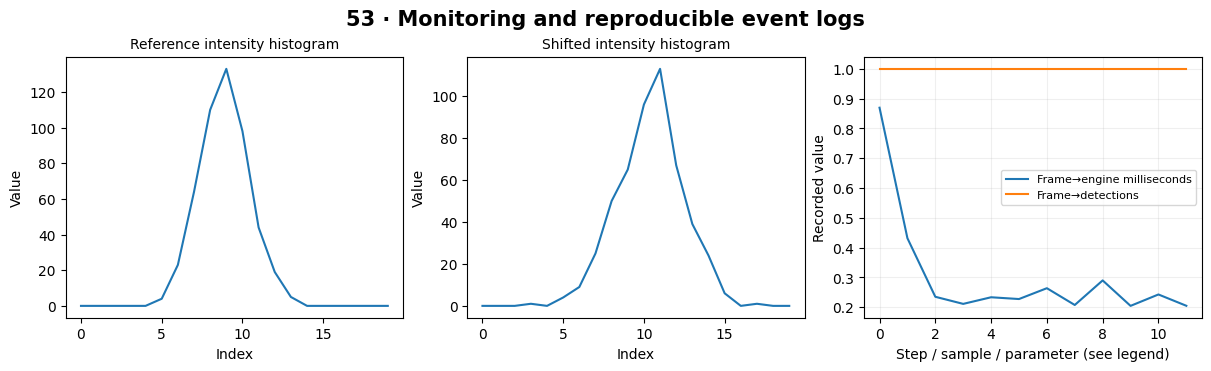

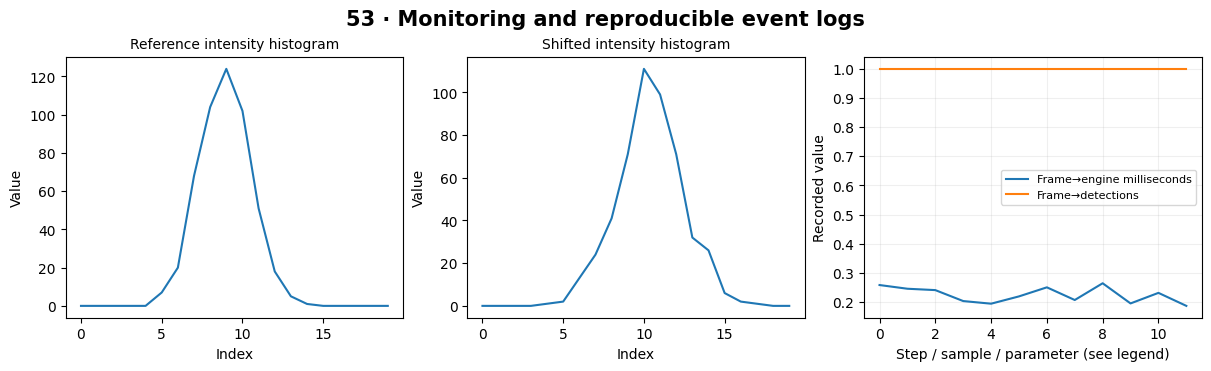

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **End-to-End Real-Time Vision Platform**. Integrate, monitor and evaluate an end-to-end vision service. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

No drift alert does not imply no accuracy degradation. A dashboard full of metrics is unhelpful without thresholds, ownership and response actions.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Introduce a brightness shift without changing object labels, then a label change without a large brightness shift. Explain which monitoring signal detects each.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Run a controlled model-release exercise with a baseline, acceptance criteria, a simulated regression and a verified rollback procedure.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Record model version, preprocessing version, label map and configuration with every deployment. Log bounded metadata and avoid unnecessary image retention. Track errors, request counts and latency distributions. A reproducible artifact allows a previous model to be restored when a release causes a regression.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Data drift and quality monitoring** in this chapter.

[Primary reference](https://docs.python.org/3/library/logging.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)